<a href="https://colab.research.google.com/github/jaeyong3126/SHIELD_DOC/blob/main/data/total_datasets_preprocessed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install konlpy pypdf python-docx

In [2]:
%cd /content/drive/MyDrive/SHIELD_DOC
!git pull

/content/drive/MyDrive/SHIELD_DOC
Already up to date.


In [3]:
!pip install -r requirements.txt

In [39]:
import sys
import os
import pandas as pd
import re
from tqdm import tqdm
from collections import Counter
from konlpy.tag import Okt
import importlib

# 환경 설정 및 모듈 불러오기

sys.path.append('/content/drive/MyDrive/SHIELD_DOC')

try:
    from tools.parser import parse_document
    from tools.pii_detector import detect_pii
except ImportError as e:
    print(f"모듈 로드 실패: {e}. 경로를 확인해 주세요.")

# 문서 파싱 및 기초 데이터셋 병합 (기밀 + 정상)

print("문서 파싱 및 기초 데이터셋 병합 시작...")

def parse_folder_to_list(folder_path, label):
    data_list = []
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            try:
                parsed_data = parse_document(file_path)
                if parsed_data["text"].strip():
                    data_list.append({
                        "filename": parsed_data["filename"],
                        "text": parsed_data["text"],
                        "label": label
                    })
            except Exception as e:
                print(f"파싱 실패 ({filename}): {e}")
    return data_list

# 기밀(1) 및 정상(0) 문서 파싱
confidential_dir = '/content/drive/MyDrive/Confidential/'
normal_dir = '/content/drive/MyDrive/Normal/'

conf_list = parse_folder_to_list(confidential_dir, 1)
norm_list = parse_folder_to_list(normal_dir, 0)

# 두 데이터 합치기 (Concat)
df_datasets = pd.concat([pd.DataFrame(conf_list), pd.DataFrame(norm_list)], ignore_index=True)
print(f"(총 {len(df_datasets)}건: 기밀 {len(conf_list)}건 / 정상 {len(norm_list)}건)")


# 특수문자 정제 및 PII 마스킹

print("1차 텍스트 정제 및 개인정보(PII) 마스킹 시작...")

def clean_text_basic(text):
    if pd.isna(text) or not text: return ''
    text = re.sub(r'[^가-힣a-zA-Z0-9\s\[\]_]', ' ', str(text))
    return re.sub(r'\s+', ' ', text).strip()

processed_data = []
for index, row in tqdm(df_datasets.iterrows(), total=len(df_datasets), desc="마스킹 및 정제"):
    original_text = row['text']
    pii_result = detect_pii(original_text) # 개인정보 마스킹
    masked_text = pii_result.get("masked_text", original_text)
    processed_data.append(clean_text_basic(masked_text))

df_datasets['cleaned_text'] = processed_data

# 결측치 1차 제거
df_clean = df_datasets[df_datasets['cleaned_text'] != ''].copy()


# 중복 데이터 제거

before_count = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['cleaned_text'], keep='first')
df_clean.reset_index(drop=True, inplace=True)
after_count = len(df_clean)

print(f"{before_count}건 ➔ {after_count}건 (삭제 {before_count - after_count}건)")


# 토큰화, 소문자화, 숫자제거
okt = Okt()
standard_stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다','입니다','있습니다','합니다','됨','음','수','것','및','등','본','이','있','하','그','되','보','않','없','나','사람','주','아니','같','우리','때','년','지','대하','오','말','일','그렇','위하','때문','그것','두','말하','알','그러나','받','못하','그런','또','문제','더','사회','많','그리고','좋','크','따르','중','나오','가지','씨','시키','만들','지금','생각하','그러','속','하나','집','살','모르','적','월','데','자신','안','어떤','내','내다','경우','명','생각','시간','그녀','다시','이런','앞','보이','번','다른',
                      '어떻','여자','개','전','사실','이렇','점','싶','정도','원','통하','소리','놓','있다', '되다', '이다', '않다', '되어다', '같다', '그렇다', '많다', '들다', '나다', '받다', '가다',
                      '오다', '알다', '주다', '이런', '저런', '어떤', '빠지다', '걸리다', '드리다']
domain_stopwords = ['한빛', '반도체', '당사', '부서', '문서', '위해', '대상', '내용', '사항', '관련', '참고', '확인', '작성', '이용', '정리', '기준','hanbit', 'semiconductor', 'corporate', 'document', 'example', 'semi', 'ra',
                    'g', 'a', 's', 'nm', 'mcu', 'vip', '가표', '밉다','com', 'co', 'kr', 'net', 'www','hbs', 'hr', 'emg', 'acc', 'wel','늘다', '보다', '따르다', '이번']
stopwords = list(set(standard_stopwords + domain_stopwords))

def extract_and_polish(text):
    if not isinstance(text, str): return ""

    # 형태소 분석 및 불용어 제거
    morphs = okt.pos(text, stem=True)
    words = []
    for word, pos in morphs:
        if pos in ['Noun', 'Verb', 'Adjective', 'Alpha']:
            if word not in stopwords and (len(word) > 1 or pos in ['Alpha']):
                words.append(word)

    # 소문자화 및 숫자 제거
    joined_text = " ".join(words).lower()
    joined_text = re.sub(r'\d+', ' ', joined_text)
    return re.sub(r'\s+', ' ', joined_text).strip()

tqdm.pandas()
df_clean['final_tokens'] = df_clean['cleaned_text'].progress_apply(extract_and_polish)

# 전처리 후 결측치 확인 및 제거
df_clean = df_clean[df_clean['final_tokens'] != '']

# 중복 파일 제거
before_count_1 = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['final_tokens'], keep='first')
df_clean.reset_index(drop=True, inplace=True)
after_count_1 = len(df_clean)
print(f"{before_count_1}건 ➔ {after_count_1}건 (삭제 {before_count_1 - after_count_1}건)")

# 최종 파일 하나로 깔끔하게 저장

print("최종 데이터셋 저장")

# 필요한 핵심 컬럼만 추려서 저장
df_final_output = df_clean[['filename', 'label', 'final_tokens']]
final_path = '/content/drive/MyDrive/Module_proj1/final_datasets.csv'
df_final_output.to_csv(final_path, index=False, encoding='utf-8-sig')

print(f"파일이 성공적으로 저장되었습니다.")
print(f"저장 경로: {final_path}")

display(df_final_output.head(3))

문서 파싱 및 기초 데이터셋 병합 시작...
(총 1890건: 기밀 1223건 / 정상 667건)
1차 텍스트 정제 및 개인정보(PII) 마스킹 시작...


마스킹 및 정제: 100%|██████████| 1890/1890 [02:20<00:00, 13.43it/s]


1890건 ➔ 1890건 (삭제 0건)


100%|██████████| 1890/1890 [00:58<00:00, 32.12it/s]


1890건 ➔ 1740건 (삭제 150건)
최종 데이터셋 저장
파일이 성공적으로 저장되었습니다.
저장 경로: /content/drive/MyDrive/Module_proj1/final_datasets.csv


,filename,label,final_tokens
0,pii_jeh_064.txt,1,복리 후생 시스템 경조사 지원 신청서 신청 번호 hbs wel 신청 일자 접수 직원...
1,pii_jeh_059.txt,1,복리 후생 시스템 경조사 지원 신청서 신청 번호 hbs wel 신청 일자 접수 직원...
2,pii_jeh_065.txt,1,사업 안전 보안 비상 연락망 번호 hbs emg 최종 정일 관리 비상 연락망 사업 ...


폰트 설정 완료. 전처리 전(Raw Dataset) 시각화 생성 중...


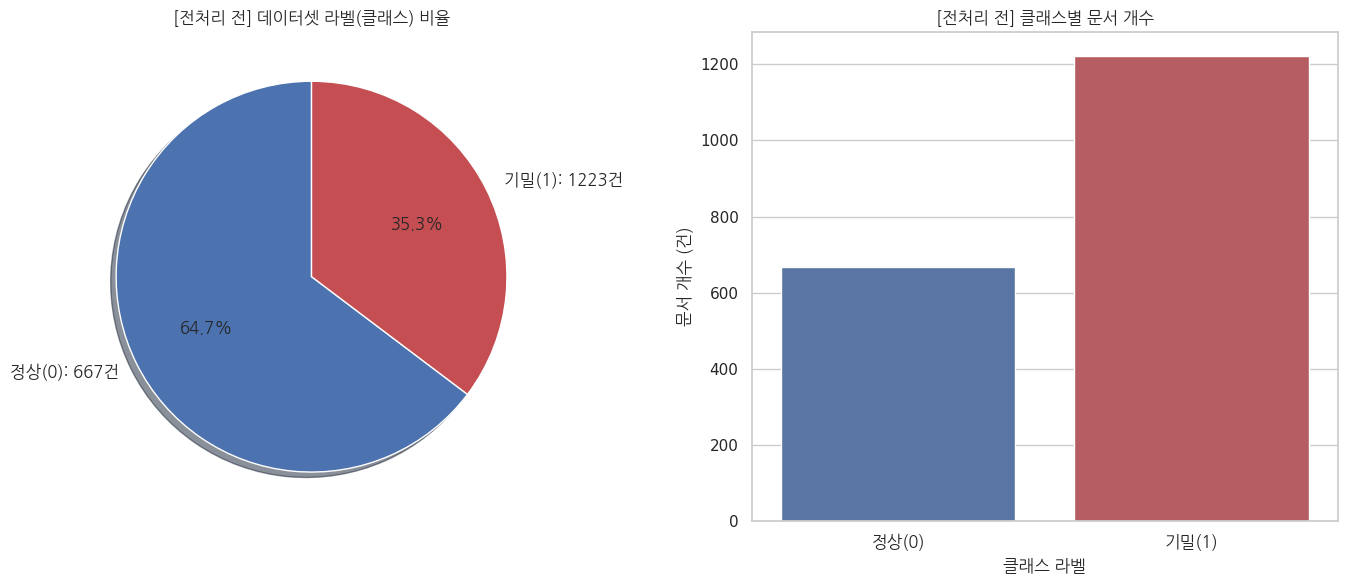

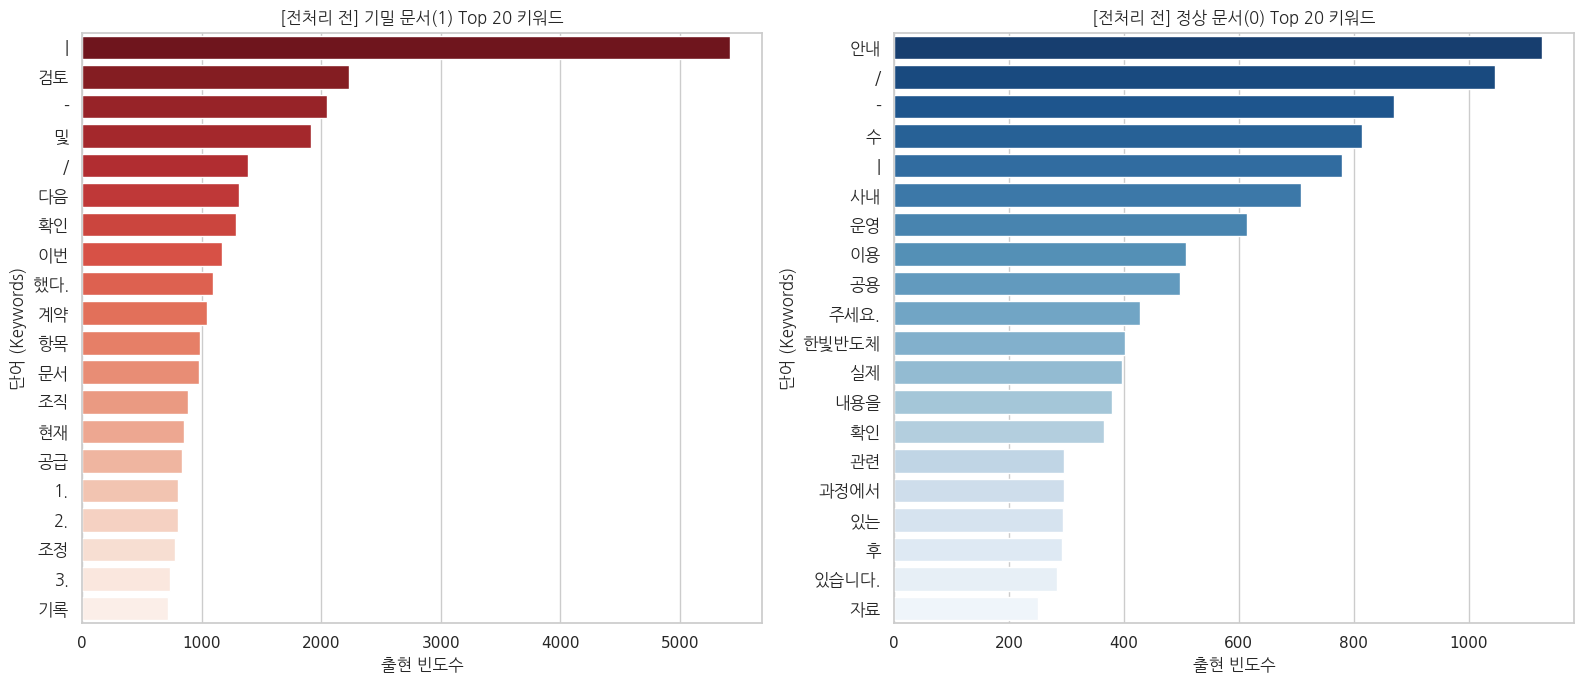

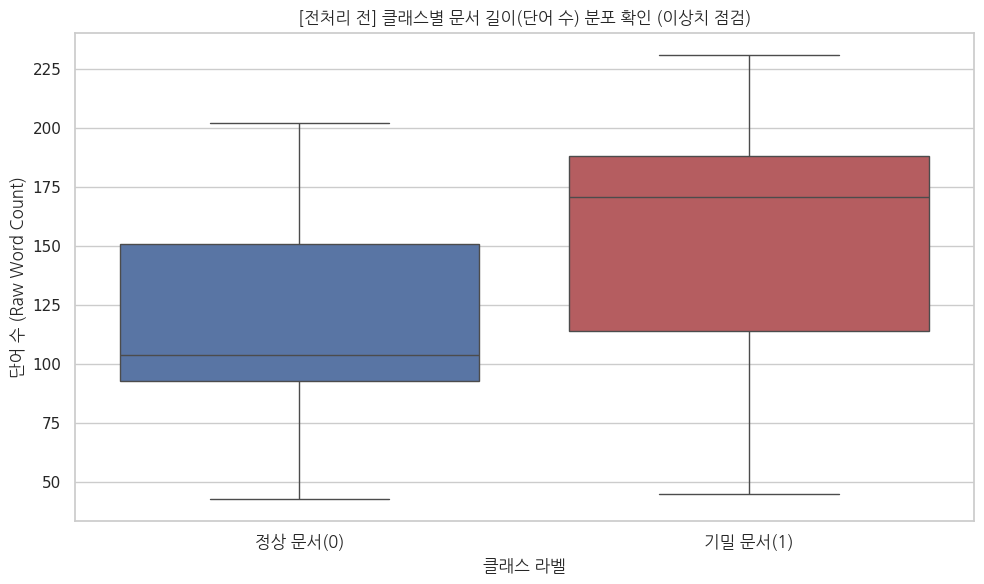

전처리 후 EDA (최적화 완료)


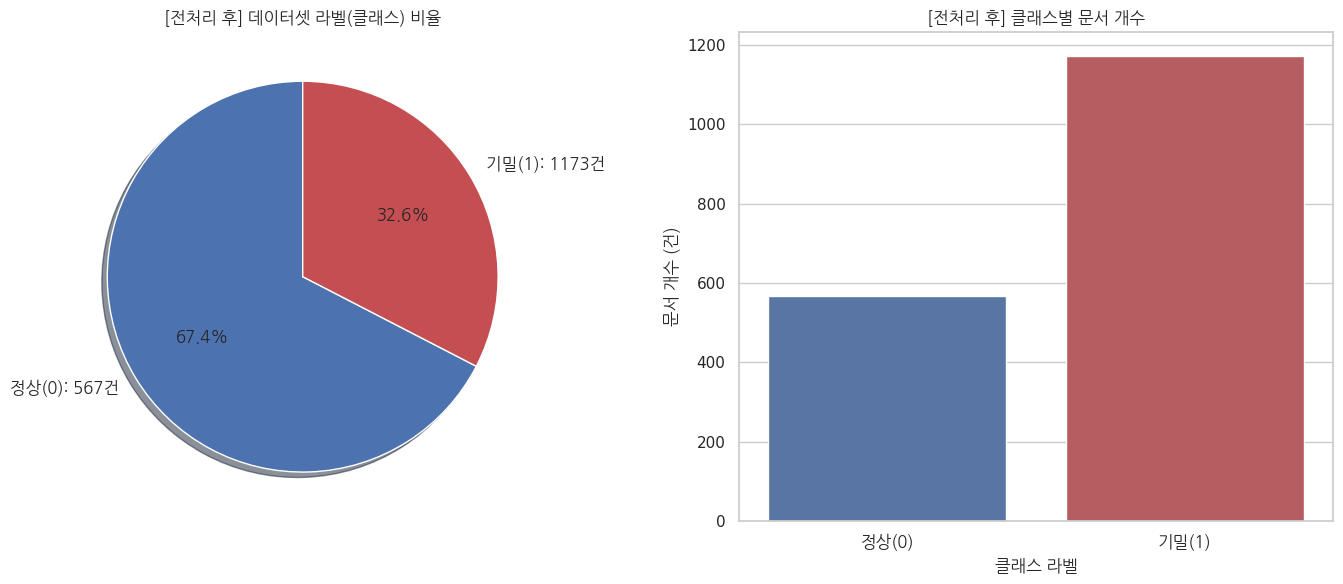

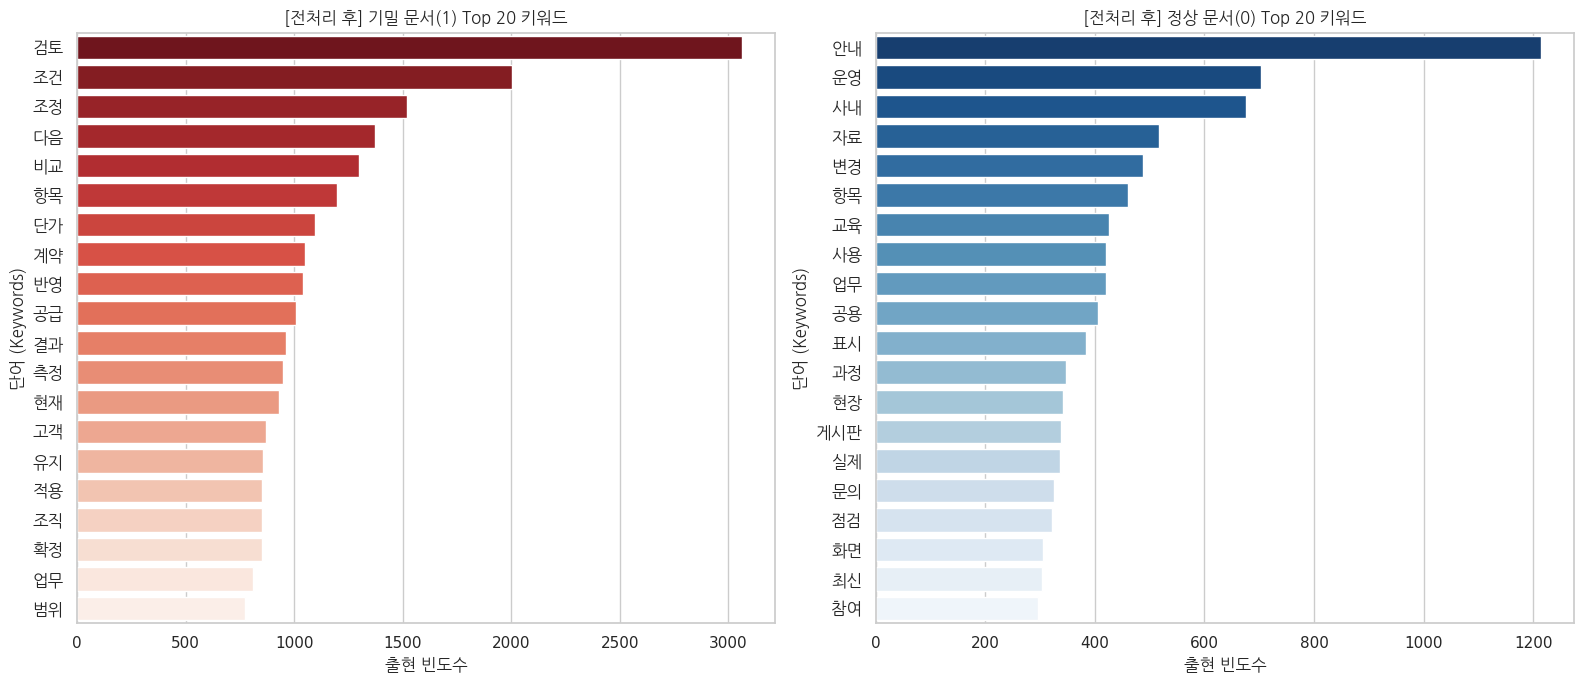

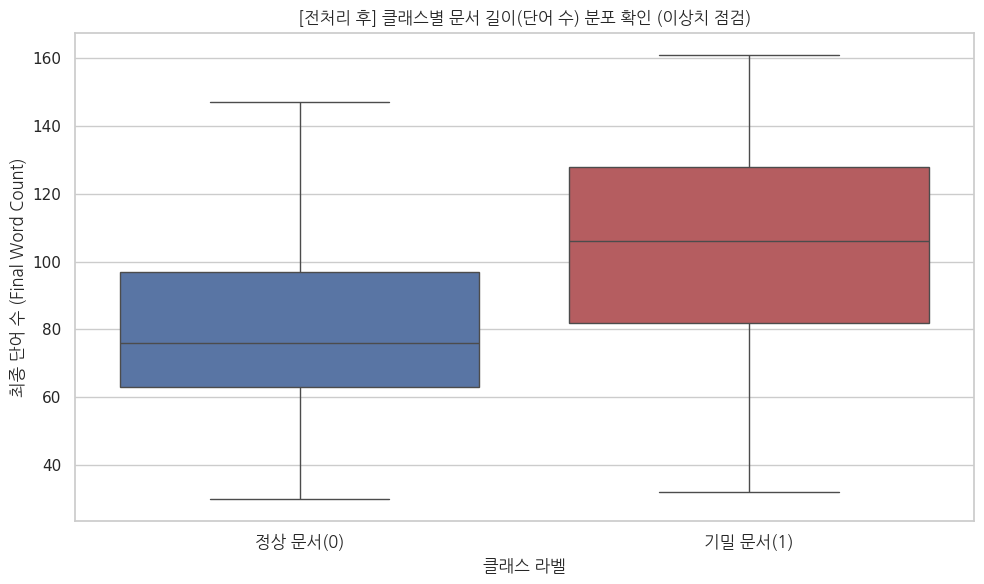

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import matplotlib.font_manager as fm
import urllib.request
import os
import pandas as pd


# 나눔고딕 폰트 다운로드 및 직접 참조 객체 생성
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
font_path = "NanumGothic.ttf"

if not os.path.exists(font_path):
    print("나눔고딕 폰트 다운로드 중...")
    urllib.request.urlretrieve(font_url, font_path)

# 맷플롯립에 폰트 등록 및 명시적 폰트 객체 선언
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

print("폰트 설정 완료. 전처리 전(Raw Dataset) 시각화 생성 중...")


# [전처리 전 EDA 분석 및 시각화]

# 원본 라벨 비율
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
label_counts = df_datasets['label'].value_counts()

# 파이 차트
axes[0].pie(label_counts,
            labels=[f"정상(0): {label_counts.get(0, 0)}건", f"기밀(1): {label_counts.get(1, 0)}건"],
            autopct='%1.1f%%',
            startangle=90,
            colors=['#4C72B0', '#C44E52'],
            shadow=True,
            textprops={'fontproperties': font_prop})
axes[0].set_title('[전처리 전] 데이터셋 라벨(클래스) 비율', fontsize=14, fontweight='bold', fontproperties=font_prop)

# 바 차트 (Countplot)
sns.countplot(data=df_datasets, x='label', hue='label', ax=axes[1], palette=['#4C72B0', '#C44E52'], legend=False)
axes[1].set_title('[전처리 전] 클래스별 문서 개수', fontsize=14, fontweight='bold', fontproperties=font_prop)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['정상(0)', '기밀(1)'], fontproperties=font_prop)
axes[1].set_ylabel('문서 개수 (건)', fontproperties=font_prop)
axes[1].set_xlabel('클래스 라벨', fontproperties=font_prop)

plt.tight_layout()
plt.show()

# 원본 텍스트 기준 Top 20 단어 빈도수 시각화
def get_raw_top_words(df, label_value, top_n=20):
    target_texts = df[df['label'] == label_value]['text'].astype(str)
    all_words = []
    for text in target_texts:
        words = text.split()
        all_words.extend(words)
    counter = Counter(all_words)
    return counter.most_common(top_n)

conf_top20 = get_raw_top_words(df_datasets, label_value=1, top_n=20)
norm_top20 = get_raw_top_words(df_datasets, label_value=0, top_n=20)

df_conf_top20 = pd.DataFrame(conf_top20, columns=['Word', 'Count'])
df_norm_top20 = pd.DataFrame(norm_top20, columns=['Word', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 기밀 문서 Top 20
sns.barplot(data=df_conf_top20, x='Count', y='Word', hue='Word', ax=axes[0], palette='Reds_r', legend=False)
axes[0].set_title('[전처리 전] 기밀 문서(1) Top 20 키워드', fontsize=14, fontweight='bold', fontproperties=font_prop)
axes[0].set_xlabel('출현 빈도수', fontproperties=font_prop)
axes[0].set_ylabel('단어 (Keywords)', fontproperties=font_prop)
for label in axes[0].get_yticklabels():
    label.set_fontproperties(font_prop)

# 정상 문서 Top 20
sns.barplot(data=df_norm_top20, x='Count', y='Word', hue='Word', ax=axes[1], palette='Blues_r', legend=False)
axes[1].set_title('[전처리 전] 정상 문서(0) Top 20 키워드', fontsize=14, fontweight='bold', fontproperties=font_prop)
axes[1].set_xlabel('출현 빈도수', fontproperties=font_prop)
axes[1].set_ylabel('단어 (Keywords)', fontproperties=font_prop)
for label in axes[1].get_yticklabels():
    label.set_fontproperties(font_prop)

plt.tight_layout()
plt.show()

# 원본 문서 길이 분포
if 'raw_word_count' not in df_datasets.columns:
    df_datasets['raw_word_count'] = df_datasets['text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_datasets, x='label', y='raw_word_count', hue='label', palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('[전처리 전] 클래스별 문서 길이(단어 수) 분포 확인 (이상치 점검)', fontsize=14, fontweight='bold', fontproperties=font_prop)
plt.xticks([0, 1], ['정상 문서(0)', '기밀 문서(1)'], fontproperties=font_prop)
plt.xlabel('클래스 라벨', fontproperties=font_prop)
plt.ylabel('단어 수 (Raw Word Count)', fontproperties=font_prop)

plt.tight_layout()
plt.show()


# [전처리 후 EDA 분석 및 시각화]

print("="*50)
print("전처리 후 EDA (최적화 완료)")
print("="*50)

# 정상(0) vs 기밀(1) 라벨 비율
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
label_counts = df_clean['label'].value_counts()

# 파이 차트
axes[0].pie(label_counts,
            labels=[f"정상(0): {label_counts.get(0, 0)}건", f"기밀(1): {label_counts.get(1, 0)}건"],
            autopct='%1.1f%%',
            startangle=90,
            colors=['#4C72B0', '#C44E52'],
            shadow=True,
            textprops={'fontproperties': font_prop})
axes[0].set_title('[전처리 후] 데이터셋 라벨(클래스) 비율', fontsize=14, fontweight='bold', fontproperties=font_prop)

# 바 차트
sns.countplot(data=df_clean, x='label', hue='label', ax=axes[1], palette=['#4C72B0', '#C44E52'], legend=False)
axes[1].set_title('[전처리 후] 클래스별 문서 개수', fontsize=14, fontweight='bold', fontproperties=font_prop)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['정상(0)', '기밀(1)'], fontproperties=font_prop)
axes[1].set_ylabel('문서 개수 (건)', fontproperties=font_prop)
axes[1].set_xlabel('클래스 라벨', fontproperties=font_prop)

plt.tight_layout()
plt.show()


# 기밀 vs 정상 문서 Top 20 단어 빈도수

def get_final_top_words(df, label_value, top_n=20):
    target_texts = df[df['label'] == label_value]['final_tokens'].astype(str)
    all_words = []
    for text in target_texts:
        all_words.extend(text.split())
    return Counter(all_words).most_common(top_n)

conf_top20 = get_final_top_words(df_clean, label_value=1, top_n=20)
norm_top20 = get_final_top_words(df_clean, label_value=0, top_n=20)

df_conf_top20 = pd.DataFrame(conf_top20, columns=['Word', 'Count'])
df_norm_top20 = pd.DataFrame(norm_top20, columns=['Word', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 기밀 문서 Top 20
sns.barplot(data=df_conf_top20, x='Count', y='Word', hue='Word', ax=axes[0], palette='Reds_r', legend=False)
axes[0].set_title('[전처리 후] 기밀 문서(1) Top 20 키워드', fontsize=14, fontweight='bold', fontproperties=font_prop)
axes[0].set_xlabel('출현 빈도수', fontproperties=font_prop)
axes[0].set_ylabel('단어 (Keywords)', fontproperties=font_prop)
for label in axes[0].get_yticklabels():
    label.set_fontproperties(font_prop)

# 정상 문서 Top 20
sns.barplot(data=df_norm_top20, x='Count', y='Word', hue='Word', ax=axes[1], palette='Blues_r', legend=False)
axes[1].set_title('[전처리 후] 정상 문서(0) Top 20 키워드', fontsize=14, fontweight='bold', fontproperties=font_prop)
axes[1].set_xlabel('출현 빈도수', fontproperties=font_prop)
axes[1].set_ylabel('단어 (Keywords)', fontproperties=font_prop)
for label in axes[1].get_yticklabels():
    label.set_fontproperties(font_prop)

plt.tight_layout()
plt.show()


# 클래스별 문서 길이 분포
df_clean['word_count'] = df_clean['final_tokens'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='label', y='word_count', hue='label', palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('[전처리 후] 클래스별 문서 길이(단어 수) 분포 확인 (이상치 점검)', fontsize=14, fontweight='bold', fontproperties=font_prop)
plt.xticks([0, 1], ['정상 문서(0)', '기밀 문서(1)'], fontproperties=font_prop)
plt.xlabel('클래스 라벨', fontproperties=font_prop)
plt.ylabel('최종 단어 수 (Final Word Count)', fontproperties=font_prop)

plt.tight_layout()
plt.show()